In [1]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────
BASE_DIR      = Path().resolve().parent
RAW_DIR       = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR :", BASE_DIR)
print("RAW_DIR  :", RAW_DIR)
print("Files    :", os.listdir(RAW_DIR))

BASE_DIR : C:\Users\theyo\OneDrive\Desktop\DS task\MYNA-Myntra-AI-Stylist
RAW_DIR  : C:\Users\theyo\OneDrive\Desktop\DS task\MYNA-Myntra-AI-Stylist\data\raw
Files    : ['images', 'myntra202305041052.csv', 'myntra202305041052.csv.zip', 'styles.csv', 'styles.csv.zip', 'user_uploads']


In [3]:
# ── Extract zip if needed ──────────────────────────────────────
zip_path = RAW_DIR / "myntra202305041052.csv.zip"
csv_path = RAW_DIR / "myntra202305041052.csv"

if zip_path.exists() and not csv_path.exists():
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(RAW_DIR)
    print("Done!")

# ── Load ───────────────────────────────────────────────────────
df = pd.read_csv(csv_path, encoding='utf-8', on_bad_lines='skip')

print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
df.head(3)

Shape   : (1060213, 11)
Columns : ['id', 'name', 'img', 'asin', 'price', 'mrp', 'rating', 'ratingTotal', 'discount', 'seller', 'purl']


,id,name,img,asin,price,mrp,rating,ratingTotal,discount,seller,purl
0,1,Men Solid Oversized Cotton,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",-,532.0,1299.0,4.1,5300,59,Difference of Opinion,https://www.myntra.com/tshirts/difference-of-o...
1,2,Men Cotton Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",-,274.0,499.0,4.2,25400,45,Roadster,https://www.myntra.com/tshirts/roadster/roadst...
2,3,Women Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",-,551.0,1199.0,4.5,3400,54,DILLINGER,https://www.myntra.com/tshirts/dillinger/dilli...


In [4]:
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("NULL VALUES")
print("=" * 50)
null_df = pd.DataFrame({
    'null_count'  : df.isnull().sum(),
    'null_percent': (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_df)

print("\n" + "=" * 50)
print("SAMPLE VALUES PER COLUMN")
print("=" * 50)
for col in df.columns:
    print(f"\n[{col}] → {df[col].dropna().unique()[:4]}")

DATA TYPES
id               int64
name            object
img             object
asin            object
price          float64
mrp            float64
rating         float64
ratingTotal      int64
discount         int64
seller          object
purl            object
dtype: object

NULL VALUES
             null_count  null_percent
id                    0           0.0
name                  0           0.0
img                   0           0.0
asin                  0           0.0
price                 0           0.0
mrp                   0           0.0
rating                0           0.0
ratingTotal           0           0.0
discount              0           0.0
seller                0           0.0
purl                  0           0.0

SAMPLE VALUES PER COLUMN

[id] → [1 2 3 4]

[name] → ['Men Solid Oversized Cotton' 'Men Cotton Pure Cotton T-shirt'
 'Women Pure Cotton T-shirt' 'Typography Print T-shirt']

[img] → ['https://assets.myntassets.com/f_webp,dpr_1.0,q_60,w_210,c_limit,fl_p

In [5]:
df2 = df.copy()

# ── Rename raw columns to standard readable names ─────────────
df2 = df2.rename(columns={
    'id'          : 'product_id',
    'img'         : 'image_url',
    'purl'        : 'product_url',
    'seller'      : 'brand',
    'ratingTotal' : 'rating_count'
})

# ── Drop useless column (all nulls) ───────────────────────────
df2 = df2.drop(columns=['asin'], errors='ignore')

print("Columns after rename:", list(df2.columns))
print(f"Shape: {df2.shape}")
df2.head(3)

Columns after rename: ['product_id', 'name', 'image_url', 'price', 'mrp', 'rating', 'rating_count', 'discount', 'brand', 'product_url']
Shape: (1060213, 10)


,product_id,name,image_url,price,mrp,rating,rating_count,discount,brand,product_url
0,1,Men Solid Oversized Cotton,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",532.0,1299.0,4.1,5300,59,Difference of Opinion,https://www.myntra.com/tshirts/difference-of-o...
1,2,Men Cotton Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",274.0,499.0,4.2,25400,45,Roadster,https://www.myntra.com/tshirts/roadster/roadst...
2,3,Women Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",551.0,1199.0,4.5,3400,54,DILLINGER,https://www.myntra.com/tshirts/dillinger/dilli...


In [6]:
# ── Convert price & mrp to numeric ────────────────────────────
df2['price'] = pd.to_numeric(df2['price'], errors='coerce')
df2['mrp']   = pd.to_numeric(df2['mrp'],   errors='coerce')

before = len(df2)

# ── Remove impossible prices ───────────────────────────────────
df2 = df2[(df2['price'] > 0) & (df2['price'] < 50000)]
df2 = df2.dropna(subset=['price'])

print(f"Removed {before - len(df2):,} rows with bad prices")
print(f"Price range : ₹{df2['price'].min():.0f} — ₹{df2['price'].max():.0f}")
print(f"Average     : ₹{df2['price'].mean():.0f}")
print(f"Remaining   : {len(df2):,} rows")

Removed 186 rows with bad prices
Price range : ₹25 — ₹49999
Average     : ₹1524
Remaining   : 1,060,027 rows


In [7]:
# Cell 6 — FIXED: Extract Gender from Name
def extract_gender(name):
    """
    Properly separate:
    Men    → adult male
    Women  → adult female
    Boys   → male children
    Girls  → female children
    Unisex → no gender mentioned
    """
    if pd.isna(name):
        return 'Unisex'

    name = str(name).lower()

    # ── Check children FIRST (before men/women) ───────────────
    # This is critical — "boys" contains "boy" which was
    # wrongly matching men. Check boys/girls FIRST.
    if 'girls' in name or "girl's" in name:
        return 'Girls'
    elif 'boys' in name or "boy's" in name:
        return 'Boys'

    # ── Then check adults ──────────────────────────────────────
    elif any(w in name for w in ['women', 'woman', 'female',
                                  'ladies', 'lady', "women's"]):
        return 'Women'
    elif any(w in name for w in ['men', 'man', 'male',
                                  'gents', "men's"]):
        return 'Men'

    return 'Unisex'

df2['gender'] = df2['name'].apply(extract_gender)

print("Gender distribution (FIXED):")
print(df2['gender'].value_counts())

Gender distribution (FIXED):
gender
Unisex    642369
Men       211679
Women     146792
Boys       43087
Girls      16100
Name: count, dtype: int64


In [8]:
# ── Define word lists for each category ───────────────────────

TOP_LAST_WORDS = {
    'top', 'tops', 'dress', 'dresses', 'gown', 'gowns',
    'shirt', 'shirts', 'tshirt', 'tshirts', 'kurta', 'kurtas',
    'kurti', 'kurtis', 'blouse', 'blouses', 'saree', 'sarees',
    'jacket', 'jackets', 'hoodie', 'hoodies', 'sweater', 'sweaters',
    'blazer', 'blazers', 'coat', 'coats', 'shrug', 'shrugs',
    'cardigan', 'cardigans', 'vest', 'vests', 'tunic', 'tunics',
    'jumpsuit', 'jumpsuits', 'romper', 'rompers', 'bodysuit',
    'lehenga', 'lehengas', 'anarkali', 'suit', 'suits',
    'sweatshirt', 'sweatshirts', 'polo', 'polos', 'camisole',
    'kaftan', 'kaftans', 'poncho', 'ponchos', 'dungaree',
    'dungarees', 'tracksuit', 'tracksuits', 'bralette',
    'bodycon', 'halter', 'crop', 'corset', 'bustier',
    'ethnic', 'salwar', 'kameez', 'churidar'
}

BOTTOM_LAST_WORDS = {
    'jeans', 'trouser', 'trousers', 'pant', 'pants',
    'shorts', 'short', 'skirt', 'skirts', 'legging', 'leggings',
    'dhoti', 'dhotis', 'tights', 'jeggings', 'jogger', 'joggers',
    'palazzos', 'palazzo', 'chino', 'chinos', 'capri', 'capris',
    'bermuda', 'bermudas', 'cargo', 'cargos', 'culotte', 'culottes',
    'brief', 'briefs', 'trunk', 'trunks', 'boxer', 'boxers',
    'trackpant', 'trackpants', 'lungi', 'bottom', 'bottoms',
    'inner', 'inners', 'innerwear', 'patiyala', 'sarong'
}

FOOTWEAR_LAST_WORDS = {
    'shoe', 'shoes', 'sandal', 'sandals', 'heel', 'heels',
    'boot', 'boots', 'sneaker', 'sneakers', 'slipper', 'slippers',
    'loafer', 'loafers', 'flat', 'flats', 'wedge', 'wedges',
    'mule', 'mules', 'espadrille', 'espadrilles', 'stiletto',
    'kolhapuri', 'jutti', 'juttis', 'mojari', 'mojaris',
    'clog', 'clogs', 'thongs', 'platform', 'footwear',
    'flipflop', 'flipflops', 'chappal', 'chappals'
}

ACCESSORIES_LAST_WORDS = {
    'bag', 'bags', 'handbag', 'handbags', 'tote', 'totes',
    'backpack', 'backpacks', 'clutch', 'clutches', 'wallet', 'wallets',
    'purse', 'purses', 'watch', 'watches', 'bracelet', 'bracelets',
    'necklace', 'necklaces', 'earring', 'earrings', 'ring', 'rings',
    'bangle', 'bangles', 'anklet', 'anklets', 'chain', 'chains',
    'pendant', 'pendants', 'sunglass', 'sunglasses', 'goggles',
    'belt', 'belts', 'cap', 'caps', 'hat', 'hats', 'beanie', 'beanies',
    'scarf', 'scarves', 'stole', 'stoles', 'muffler', 'mufflers',
    'sock', 'socks', 'gloves', 'dupatta', 'dupattas', 'shawl', 'shawls',
    'bra', 'bras', 'mask', 'masks', 'tie', 'ties', 'brooch',
    'cufflinks', 'scrunchie', 'hairband', 'tiara', 'maangtikka'
}

# ── Non-fashion words → DROP these rows ───────────────────────
DROP_WORDS = {
    # liquids / personal care
    'ml', '100ml', '200ml', '50ml', '30ml', '500ml',
    'oil', 'oils', 'cream', 'creams', 'wash', 'serum',
    'lotion', 'moisturizer', 'shampoo', 'conditioner',
    'soap', 'scrub', 'toner', 'gel', 'spray', 'deodorant',
    'sunscreen', 'foundation', 'lipstick', 'kajal',
    'mascara', 'eyeliner', 'g', 'gm', 'mg', 'kg',
    # home decor
    'lamp', 'pillow', 'cushion', 'mattress', 'bedsheet',
    'blanket', 'curtain', 'towel', 'mat', 'rug', 'vase',
    'candle', 'clock', 'frame', 'mug', 'bottle', 'bowl',
    'plate', 'box', 'shelf', 'mirror', 'poster',
    # electronics / covers
    'case', 'cases', 'cover', 'covers', 'charger', 'cable',
    'earphone', 'headphone', 'speaker', 'stand', 'mount',
    # misc non-fashion
    'rakhi', 'rakhis', 'diya', 'diyas', 'incense',
    'notebook', 'diary', 'pen', 'plant', 'seeds',
    'mat', 'dumbbell', 'bottle'
}

# ── "set" is ambiguous — check full name ──────────────────────
def handle_set(name):
    """
    'Kurta Set'      → Top
    'Jewellery Set'  → Accessories
    'Grooming Set'   → Drop
    'Bedsheet Set'   → Drop
    """
    if any(w in name for w in ['kurta', 'kurti', 'saree', 'lehenga',
                                'shirt', 'dress', 'suit', 'ethnic']):
        return 'Top'
    elif any(w in name for w in ['jewel', 'earring', 'necklace',
                                  'bangle', 'bracelet', 'ring']):
        return 'Accessories'
    elif any(w in name for w in ['jeans', 'pant', 'trouser', 'shorts']):
        return 'Bottom'
    else:
        return 'Drop'

# ── Main component extraction function ────────────────────────
def extract_component(name):
    """
    Logic order:
    1. Get last word → most product names end with product type
       e.g. 'Embroidered Georgette Top' → last word = 'top' → Top
    2. If last word is DROP → mark Drop
    3. If last word matches a category → assign it
    4. If last word is 'set' → use handle_set logic
    5. If last word not matched → scan FULL name for keywords
    6. If nothing matches → Drop (not useful for MYNA)
    """
    if pd.isna(name):
        return 'Drop'

    name_lower = str(name).lower().strip()
    words      = name_lower.split()
    last_word  = words[-1] if words else ''

    # ── Check 1: Drop non-fashion immediately ─────────────────
    if last_word in DROP_WORDS:
        return 'Drop'

    # ── Check 2: Last word → Top ──────────────────────────────
    if last_word in TOP_LAST_WORDS:
        return 'Top'

    # ── Check 3: Last word → Bottom ───────────────────────────
    if last_word in BOTTOM_LAST_WORDS:
        return 'Bottom'

    # ── Check 4: Last word → Footwear ─────────────────────────
    if last_word in FOOTWEAR_LAST_WORDS:
        return 'Footwear'

    # ── Check 5: Last word → Accessories ──────────────────────
    if last_word in ACCESSORIES_LAST_WORDS:
        return 'Accessories'

    # ── Check 6: Handle "set" ──────────────────────────────────
    if last_word == 'set':
        return handle_set(name_lower)

    # ── Check 7: Scan full name for any fashion keyword ────────
    for word in TOP_LAST_WORDS:
        if word in name_lower:
            return 'Top'
    for word in BOTTOM_LAST_WORDS:
        if word in name_lower:
            return 'Bottom'
    for word in FOOTWEAR_LAST_WORDS:
        if word in name_lower:
            return 'Footwear'
    for word in ACCESSORIES_LAST_WORDS:
        if word in name_lower:
            return 'Accessories'

    # ── Check 8: Drop if nothing matched ──────────────────────
    return 'Drop'


# ── Apply to dataframe ─────────────────────────────────────────
df2['component_type'] = df2['name'].apply(extract_component)

print("Component type distribution (before dropping):")
print(df2['component_type'].value_counts())

Component type distribution (before dropping):
component_type
Top            359219
Drop           276819
Accessories    235446
Bottom         142906
Footwear        45637
Name: count, dtype: int64


In [9]:
# ── Color list — order matters (longer/specific first) ────────
COLORS = [
    'navy blue', 'sky blue', 'light blue', 'dark blue',
    'light pink', 'hot pink', 'dark green', 'olive green',
    'off white', 'off-white', 'multicolor', 'multi color',
    'black', 'white', 'blue', 'red', 'green', 'yellow',
    'pink', 'grey', 'gray', 'purple', 'orange', 'brown',
    'beige', 'maroon', 'navy', 'cream', 'olive', 'coral',
    'teal', 'gold', 'silver', 'printed', 'floral',
    'striped', 'checked', 'embroidered'
]

def extract_color(name):
    if pd.isna(name):
        return 'Unknown'
    name_lower = str(name).lower()
    for color in COLORS:
        if color in name_lower:
            return color.title()
    return 'Unknown'

df2['color'] = df2['name'].apply(extract_color)

print("Top 15 colors found:")
print(df2['color'].value_counts().head(15))

Top 15 colors found:
color
Unknown    742817
Printed    151452
Gold        45483
Red         38801
Striped     24901
Silver      14972
Floral      14295
Cream        5958
Checked      5780
Black        3688
Blue         2314
White        1667
Pink         1521
Green        1417
Brown         842
Name: count, dtype: int64


In [10]:
before = len(df2)

# ── Drop rows marked as non-fashion ───────────────────────────
df2 = df2[df2['component_type'] != 'Drop'].copy()
print(f"Dropped {before - len(df2):,} non-fashion rows")

# ── Drop rows with missing name ────────────────────────────────
df2 = df2.dropna(subset=['name'])

# ── Remove duplicates ──────────────────────────────────────────
before2 = len(df2)
df2 = df2.drop_duplicates(subset=['name', 'price'], keep='first')
print(f"Removed {before2 - len(df2):,} duplicate rows")

# ── Fill remaining nulls ───────────────────────────────────────
df2['brand']     = df2['brand'].fillna('Unknown')
df2['color']     = df2['color'].fillna('Unknown')
df2['image_url'] = df2['image_url'].fillna('')
df2['rating']    = pd.to_numeric(df2['rating'], errors='coerce').fillna(0)

# ── Reset index ────────────────────────────────────────────────
df2 = df2.reset_index(drop=True)

print(f"\nFinal shape: {df2.shape}")
print(f"\nFinal component types:")
print(df2['component_type'].value_counts())
print(f"\nFinal gender split:")
print(df2['gender'].value_counts())
print(f"\nPrice range: ₹{df2['price'].min():.0f} — ₹{df2['price'].max():.0f}")
df2.head(3)

Dropped 276,819 non-fashion rows
Removed 430,502 duplicate rows

Final shape: (352706, 13)

Final component types:
component_type
Top            153970
Accessories    106253
Bottom          72051
Footwear        20432
Name: count, dtype: int64

Final gender split:
gender
Unisex    184233
Men        74594
Women      62249
Boys       20154
Girls      11476
Name: count, dtype: int64

Price range: ₹45 — ₹49995


,product_id,name,image_url,price,mrp,rating,rating_count,discount,brand,product_url,gender,component_type,color
0,2,Men Cotton Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",274.0,499.0,4.2,25400,45,Roadster,https://www.myntra.com/tshirts/roadster/roadst...,Men,Top,Unknown
1,3,Women Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",551.0,1199.0,4.5,3400,54,DILLINGER,https://www.myntra.com/tshirts/dillinger/dilli...,Women,Top,Unknown
2,4,Typography Print T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",296.0,1099.0,4.0,18400,73,Huetrap,https://www.myntra.com/tshirts/huetrap/huetrap...,Unisex,Top,Unknown


In [11]:
out_path = PROCESSED_DIR / "clean_myntra_products.csv"
df2.to_csv(out_path, index=False)

print("=" * 55)
print("DATA CLEANING COMPLETE")
print("=" * 55)
print(f"Total products saved : {len(df2):,}")
print(f"Saved to             : {out_path}")
print(f"Columns              : {list(df2.columns)}")

DATA CLEANING COMPLETE
Total products saved : 352,706
Saved to             : C:\Users\theyo\OneDrive\Desktop\DS task\MYNA-Myntra-AI-Stylist\data\processed\clean_myntra_products.csv
Columns              : ['product_id', 'name', 'image_url', 'price', 'mrp', 'rating', 'rating_count', 'discount', 'brand', 'product_url', 'gender', 'component_type', 'color']


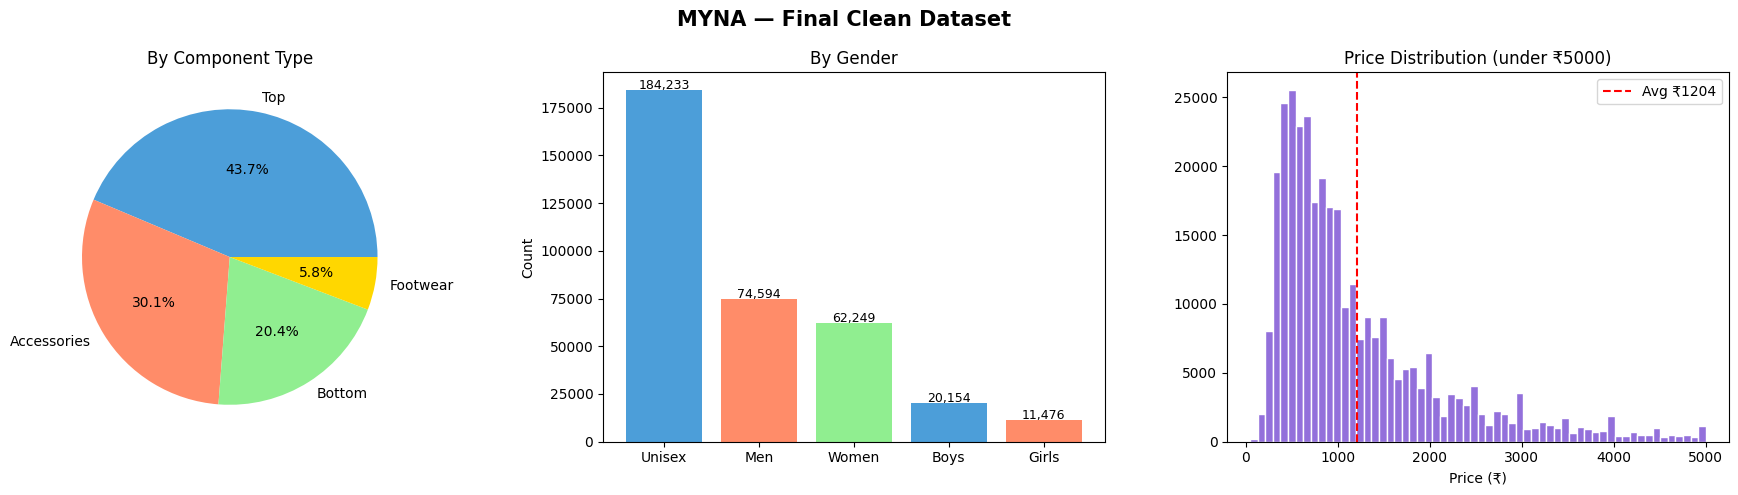

Chart saved!


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MYNA — Final Clean Dataset", fontsize=15, fontweight='bold')

# 1. Component type pie
comp = df2['component_type'].value_counts()
axes[0].pie(comp.values, labels=comp.index,
            autopct='%1.1f%%',
            colors=['#4C9ED9','#FF8C69','#90EE90','#FFD700'])
axes[0].set_title("By Component Type")

# 2. Gender bar
gen = df2['gender'].value_counts()
axes[1].bar(gen.index, gen.values,
            color=['#4C9ED9','#FF8C69','#90EE90'])
axes[1].set_title("By Gender")
axes[1].set_ylabel("Count")
for i, v in enumerate(gen.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# 3. Price distribution
price_data = df2[df2['price'] < 5000]['price']
axes[2].hist(price_data, bins=60,
             color='mediumpurple', edgecolor='white')
axes[2].axvline(price_data.mean(), color='red',
                linestyle='--',
                label=f'Avg ₹{price_data.mean():.0f}')
axes[2].set_title("Price Distribution (under ₹5000)")
axes[2].set_xlabel("Price (₹)")
axes[2].legend()

plt.tight_layout()
plt.savefig(BASE_DIR / "reports" / "final_clean_summary.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [13]:
df2

,product_id,name,image_url,price,mrp,rating,rating_count,discount,brand,product_url,gender,component_type,color
0,2,Men Cotton Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",274.0,499.0,4.2,25400,45,Roadster,https://www.myntra.com/tshirts/roadster/roadst...,Men,Top,Unknown
1,3,Women Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",551.0,1199.0,4.5,3400,54,DILLINGER,https://www.myntra.com/tshirts/dillinger/dilli...,Women,Top,Unknown
2,4,Typography Print T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",296.0,1099.0,4.0,18400,73,Huetrap,https://www.myntra.com/tshirts/huetrap/huetrap...,Unisex,Top,Unknown
3,5,Printed Round Neck Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",494.0,899.0,4.2,3800,45,Roadster,https://www.myntra.com/tshirts/roadster/roadst...,Unisex,Top,Printed
4,6,Boys Pack of 5 T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",699.0,4995.0,4.1,1200,86,HELLCAT,https://www.myntra.com/tshirts/hellcat/hellcat...,Boys,Top,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...
352701,1060197,Men Slim Fit Cargos,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",923.0,2799.0,3.6,30,67,The Indian Garage Co,https://www.myntra.com/trousers/the-indian-gar...,Men,Bottom,Unknown
352702,1060201,Men Skinny Fit Low-Rise Jeans,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",854.0,1899.0,4.3,28,55,BYFORD by Pantaloons,https://www.myntra.com/jeans/byford-by-pantalo...,Men,Bottom,Unknown
352703,1060205,Men Checked Slim Fit Cotton Track Pants,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",847.0,1695.0,0.0,0,50,Duke,https://www.myntra.com/track-pants/duke/duke-m...,Men,Bottom,Checked
352704,1060208,Men Slim Fit Track Pant,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",474.0,949.0,4.2,5,50,MASH UNLIMITED,https://www.myntra.com/track-pants/mash-unlimi...,Men,Bottom,Unknown


In [14]:
df2['component_type'].value_counts()

component_type
Top            153970
Accessories    106253
Bottom          72051
Footwear        20432
Name: count, dtype: int64

In [15]:
# Quick verification cell
import pandas as pd
from pathlib import Path

PROCESSED_DIR = Path().resolve().parent / "data" / "processed"
df_check = pd.read_csv(PROCESSED_DIR / "clean_myntra_products.csv")

print("Shape    :", df_check.shape)
print("Columns  :", list(df_check.columns))
print("\nComponent types:")
print(df_check['component_type'].value_counts())
print("\nSample rows:")
print(df_check[['name','price','gender','component_type','color']].head(5))


Shape    : (352706, 13)
Columns  : ['product_id', 'name', 'image_url', 'price', 'mrp', 'rating', 'rating_count', 'discount', 'brand', 'product_url', 'gender', 'component_type', 'color']

Component types:
component_type
Top            153970
Accessories    106253
Bottom          72051
Footwear        20432
Name: count, dtype: int64

Sample rows:
                                     name  price  gender component_type  \
0          Men Cotton Pure Cotton T-shirt  274.0     Men            Top   
1               Women Pure Cotton T-shirt  551.0   Women            Top   
2                Typography Print T-shirt  296.0  Unisex            Top   
3  Printed Round Neck Pure Cotton T-shirt  494.0  Unisex            Top   
4                  Boys Pack of 5 T-shirt  699.0    Boys            Top   

     color  
0  Unknown  
1  Unknown  
2  Unknown  
3  Printed  
4  Unknown  


In [16]:
# DIAGNOSTIC — what men's shirts actually exist in dataset?
shirts = df2[
    (df2['component_type'] == 'Top') &
    (df2['gender'].isin(['Men', 'Unisex'])) &
    (df2['name'].str.contains(r'\bshirt\b', na=False)) &
    (df2['price'] <= 2000) &
    ~(df2['name'].str.contains('women|woman|ladies|girls', na=False))
].copy()

print(f"Total men's shirts under ₹2000: {len(shirts)}")
print("\nAll shirt names in dataset:")
for name in shirts['name'].unique()[:50]:
    print(f"  {name}")

Total men's shirts under ₹2000: 33010

All shirt names in dataset:
  Men Cotton Pure Cotton T-shirt
  Typography Print T-shirt
  Printed Round Neck Pure Cotton T-shirt
  Polo Collar Cotton Pure Cotton T-shirt
  Printed Pure Cotton T-shirt
  Longline T-shirt with Raw Edge
  Printed Oversized Pure Cotton T-shirt
  Men Camouflage Printed Loose T-shirt
  Time Travlr Sleveless Pure Cotton T-shirt
  Men Striped Polo Collar T-shirt
  Henley Neck T-shirt
  Typography Cotton T-shirt
  Printed Cotton Pure Cotton T-shirt
  Solid Round Neck T-shirt
  Slim Tropical Printed Pure Cotton T-shirt
  Men Polo Collar Slim Fit T-shirt
  Colourblocked Raw Edge T-shirt
  Curl Edge Cotton T-shirt
  Men Colourblocked Polo Collar T-shirt
  Men Solid Pure Cotton T-shirt
  Drop Shoulder Longline T-shirt
  Rapid Dry Raglan Polo T-shirt
  Printed Boxy Fit T-shirt
  Polo Collar Oversized T-shirt
  Striped Henley Neck Pure Cotton T-shirt
  Printed Henley T-shirt
  Oversized Pure Cotton T-shirt
  Ultralyte Men Running

In [17]:
# What formal shirts exist specifically?
formal = df2[
    df2['name'].str.contains('formal.*shirt|shirt.*formal', na=False)
]
print(f"Total formal shirt products: {len(formal)}")
print("\nGender breakdown:")
print(formal['gender'].value_counts())
print("\nSample names:")
for name in formal['name'].unique()[:20]:
    print(f"  {name}")

Total formal shirt products: 0

Gender breakdown:
Series([], Name: count, dtype: int64)

Sample names:


In [18]:
# See what shirt types actually exist
shirt_types = df2[
    df2['name'].str.contains(r'\bshirt\b', na=False)
]['name'].str.extract(
    r'(kurta|polo|casual|check|linen|printed|'
    r'solid|oversized|slim|regular|full sleeve|'
    r'half sleeve|collar|cotton|denim)'
)[0].value_counts().head(20)
print(shirt_types)

0
cotton     41
printed    10
solid       8
polo        6
collar      5
slim        1
Name: count, dtype: int64


In [25]:
# Add USAGE column to Myntra catalog
# This tells us if a product is Formal/Casual/Ethnic/Sports

def infer_usage(name):
    """
    Infer product usage from name keywords.
    Based on patterns learned from styles.csv usage labels.
    """
    if pd.isna(name):
        return 'Casual'

    name = str(name).lower()

    # Formal
    if any(w in name for w in [
        'formal', 'office', 'business', 'professional',
        'spread collar', 'oxford', 'poplin', 'opaque',
        'slim fit shirt', 'regular fit shirt'
    ]):
        return 'Formal'

    # Ethnic
    if any(w in name for w in [
        'ethnic', 'traditional', 'kurta', 'kurti', 'saree',
        'lehenga', 'anarkali', 'salwar', 'kameez', 'dhoti',
        'sherwani', 'nehru', 'indo western', 'handloom',
        'embroidered', 'silk', 'cotton ethnic', 'pongal',
        'festival', 'pooja', 'khadi', 'bandhani', 'patola',
        'zari', 'dupatta', 'chunri', 'bandhej'
    ]):
        return 'Ethnic'

    # Sports
    if any(w in name for w in [
        'sport', 'gym', 'running', 'athletic', 'performance',
        'training', 'workout', 'active', 'dri', 'dry fit',
        'rapid dry', 'compression', 'yoga', 'cycling',
        'football', 'cricket', 'basketball', 'jersey'
    ]):
        return 'Sports'

    # Party
    # Party — add dress styles
    if any(w in name for w in [
        'party', 'bodycon', 'cocktail', 'sequin', 'shimmer',
        'gown', 'evening', 'night out', 'clubwear',
        'maxi dress', 'midi dress', 'wrap dress',    # ← ADD
        'smocked', 'embellished', 'crepe dress',     # ← ADD
        'floral dress', 'printed dress'              # ← ADD
    ]):
        return 'Party'
    # Smart Casual
    if any(w in name for w in [
        'smart', 'linen', 'chino', 'blazer', 'polo',
        'henley', 'mandarin', 'waffle', 'textured'
    ]):
        return 'Smart Casual'

    return 'Casual'

# Apply to dataframe
df2['usage'] = df2['name'].apply(infer_usage)

print("Usage distribution in Myntra catalog:")
print(df2['usage'].value_counts())

print("\nSample Formal products:")
formal = df2[df2['usage'] == 'Formal']
print(formal[['name','gender','component_type','price']].head(10))

Usage distribution in Myntra catalog:
usage
Casual          253401
Ethnic           56576
Smart Casual     16646
Sports           14050
Party             9841
Formal            2192
Name: count, dtype: int64

Sample Formal products:
                                name  gender component_type   price
463     Men Slim Fit Formal Trousers     Men         Bottom  2379.0
469              Men Formal Trousers     Men         Bottom  2099.0
549    Plus Size Opaque Casual Shirt  Unisex            Top  1429.0
923        Women Cotton Poplin Shirt   Women            Top  1039.0
935            Slim Fit Formal Shirt  Unisex            Top   779.0
1206    Men Slim Fit Formal Trousers     Men         Bottom  1919.0
1589      Spread Collar Formal Shirt  Unisex            Top   494.0
1677            Formal Bodycon Dress  Unisex            Top  3225.0
1684  Women Front-Open Formal Blazer   Women            Top  2799.0
1700      Shawl Collar Formal Blazer  Unisex            Top  4000.0


In [26]:
# Check formal shirts specifically
formal_shirts = df2[
    (df2['usage'] == 'Formal') &
    (df2['component_type'] == 'Top') &
    (df2['name'].str.contains(r'\bshirt\b', na=False))
]
print(f"Formal shirts in Myntra catalog: {len(formal_shirts)}")
print(f"\nGender split:")
print(formal_shirts['gender'].value_counts())
print(f"\nSample formal shirts:")
print(formal_shirts[['name','brand','price','gender']].head(15))

Formal shirts in Myntra catalog: 4

Gender split:
gender
Unisex    4
Name: count, dtype: int64

Sample formal shirts:
                                 name           brand   price  gender
28238   Striped Spread Collar T-shirt  Mast & Harbour   399.0  Unisex
246364   Cotton Spread Collar T-shirt        Roadster   671.0  Unisex
279931  Printed Spread Collar T-shirt  Louis Philippe  1471.0  Unisex
326553   Cotton Spread Collar T-shirt        Roadster   349.0  Unisex


In [27]:
# Re-save clean catalog with usage column
out_path = PROCESSED_DIR / "clean_myntra_products.csv"
df2.to_csv(out_path, index=False)

print("=" * 50)
print("CATALOG UPDATED WITH USAGE COLUMN")
print("=" * 50)
print(f"Total products : {len(df2):,}")
print(f"Columns        : {list(df2.columns)}")
print(f"\nUsage breakdown:")
print(df2['usage'].value_counts())

CATALOG UPDATED WITH USAGE COLUMN
Total products : 352,706
Columns        : ['product_id', 'name', 'image_url', 'price', 'mrp', 'rating', 'rating_count', 'discount', 'brand', 'product_url', 'gender', 'component_type', 'color', 'usage']

Usage breakdown:
usage
Casual          253401
Ethnic           56576
Smart Casual     16646
Sports           14050
Party             9841
Formal            2192
Name: count, dtype: int64
